<span style='font-family: Avenir; font-size:xx-large; font-weight:bolder'>
3. Data compilation from DataSheets
</span>

---
# 3A. Overview

This notebook assumes that you already:
- have [printed/assembled the drosben hardware](../hardware/README.md);
- have [installed the drosben software](../README.md);
- have [a pen marker combination that satisfies the colour calibration requirements](./01_First_Use_Colour_Calibration.ipynb)
- have [initialised an experiment by having the Drosben software create the metadata record and a directory with experiment files](./02_Perform_Experiment.ipynb)
- have printed the DataSheet PDF files for each rack; started the experiment; collected the data with the pen marker combination [as discussed earlier](../docs/img/data_recording.png); and scanned the DataSheets.

At this point you can start 'reading' the DataSheet scans to compile the survival data digitally, which is covered in this **Notebook #03**:

![overview_software](../docs/img/overview_soft3.png)


> **NOTE:** It is _not_ necessary to reach the end of the experiment to start compiling data. Drosben will digitally 'censor' all surviving flies at this point to give you the dataset as it would be if you stopped the experiment then. You can still come back with new data later and add more observations.

---
# 3B. Compile data from DataSheets of a finished experiment

In the simplest case, you will have scanned _all_ the DataSheets corresponding to a _finished_ experiment, and placed them together in a directory in your computer. We start by identifying the path to these scans, either typing the path (right below) or interactively (further below).

**INTERACTIVE OPTION:**

(Uncomment the code blocks to run it)

In [1]:
# run this code block without altering it
from pathlib import Path
from ipyfilechooser import FileChooser
home = str(Path.home()) 
fc = FileChooser(f'{home}/')
fc.title = '<b>Select your DataSheet scan folder</b>'
fc.show_only_dirs = True
display(fc)

FileChooser(path='/Users/JQ', filename='', title='<b>Select your DataSheet scan folder</b>', show_hidden=False…

In [2]:
# run this code block without altering it
scanspath = None
if 'fc' in globals() and fc.selected is not None:
    scanspath = Path(fc.selected)
    print(f'Interactive selection: {scanspath}')
else:
    print('No interactive folder selected — using the path set below, if any.')

Interactive selection: /Users/JQ/Drosben_userdata/experiments_data/02.02.2022_Effect-of-myfavouritegene-on-lifespan_bd8b2f79/processed_datasheets


**TYPING OPTION:**

In [3]:
# substitute the 'breadcrumbs' to the example with your path elements:
from pathlib import Path
scanspath_cli = Path('../tests/data/datasheet_scans')
print(f'This path IS {"" if scanspath_cli.is_dir() else "NOT "}a local folder: {str(scanspath_cli)}')

This path IS a local folder: ../tests/data/datasheet_scans


---

**Once the path has been selected:**

We check that this computer has the preexisting directory for the experiment (in case you are working across multiple independent computers):

In [4]:
# check the experiment directory exists locally:
from drosben.image.process import get_existing_experiments
infodict_list = get_existing_experiments()
infodict_list

[['/Users/JQ/Drosben_userdata/experiments_data/02.02.2022_Effect-of-myfavouritegene-on-lifespan_bd8b2f79',
  {'exp_name': 'Effect of myfavouritegene on lifespan',
   'colour_data': {'dead': {'HSinterval': [[5.7602, 6.8166], [0.5629, 0.833]],
     'RGB': [0.8588, 0.2471, 0.2824]},
    'censored': {'HSinterval': [[3.6742, 4.839], [0.47, 0.7496]],
     'RGB': [0.2784, 0.3412, 0.7255]},
    'carried-over': {'HSinterval': [[1.6937, 3.0471], [0.4337, 0.6776]],
     'RGB': [0.2824, 0.6353, 0.4431]},
    'otsuT': np.int64(141)},
   'var1': {'var1_name': 'genotype',
    'var1_lvls': ['wild-type', 'mfg[1]', nan, nan]},
   'var2': {'var2_name': 'treatment',
    'var2_lvls': ['mock', 'treated', nan, nan]},
   'init_date': '02.02.2022',
   'racks': [{'rack_no': np.int64(1),
     'var1': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=object),
     'var2': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=object),
     'fly_no': array([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10], dtype=object)

---

If you have gone through [Notebook #1](./01_First_Use_Colour_Calibration.ipynb) and [Notebook #2](./02_Perform_Experiment.ipynb) in this computer, there should be least one experiment named `Effect of myfavouritegene on lifespan` with ID `bd8b2f79-aebc-4327-9b02-fbd5f56f6210`, corresponding to the sample scans included in the repository.

The next step is to **analyse the scans**, matching them to an experiment and extracting the events (deaths, carried-overs, censorings) and time data. 
    
> DataSheet scan analysis is done with `process_DataSheet_batch()`, whose printed output is very long. This can be suppressed but here instead we will use `contextlib` and `io` to capture this output in a variable that can be printed partially/separately.


In [5]:
# prepare to capture printed output:
import contextlib
import io
buffer = io.StringIO()

# check which scanspath was 
for name in ("scanspath", "scanspath_cli"):
    p = globals().get(name)
    if isinstance(p, Path) and p.is_dir():
        used_scanspath = p
        break

with contextlib.redirect_stdout(buffer):
    # drosben function
    from drosben.experiment.manager import process_DataSheet_batch
    experiments_updated, feedback_text = process_DataSheet_batch(
        used_scanspath,
        OW=True,       # OverWrite: whether new event data will be appended
                       #            to existng data or substitute it
        dry_run=False, # If True, nothing is written to disk - only for testing
        verbose=True  # To suppress or allow printed output
    )
# captured output variable:
captured_output = buffer.getvalue()

A few comments on some arguments to `process_DataSheet_batch`:

### - `OW` to allow overwriting wrong data

`OW` refers to:
- the "extracted event data" (deaths, carried-overs and censorings at each observational time point of the experiment), and
- the "raw data" (scan images) that support the other data.

If `True` and `scanspath` contains scans of DataSheets that were already incorporated to the `Experiment`, the images of these scans and the data extracted from them will **substitute** the existing event data and existing image records of those DataSheets in `Experiment.storepath`. New data/images will be appended.

If `False`, the data recording areas that have already been processed will be ignored, and only new data will be recorded. Image records of DataSheets that had not been completed (i.e. they had less than 8 data areas filled in) will be overwritten with a new image, if the new version contains more areas with information recorded.

**This is meant for the following case uses:**
- We often want to see how an experiment is doing before it finishes, and therefore add partial data and analyse it. Then, when we add more data, it is faster if we can skip redundant analysis that we have already checked, so we make `OW=False`.
- However, some scans may not have enough resolution. Or have been recorded incorrectly, with the wrong markers, or put two event marks touching each other or the border of the tube. Maybe they got coffee spilled or a pen tested on them. We want to be able to print them again, quickly record the data using the old DataSheet, make corrections/clean up and scan again. `OW=True` is meant for this situation, when you want to remove all the previous data and supporting images. While this may seem the most 'niche' use case, `OW` by default is set to `True`.

### - `dry_run` to test the code

This is similar to `OW` but it prevents _any_ writing to disk. It is only meant for testing whether the code runs at all. It is only for troubleshooting and hopefully you will never use it as `True`. `False` is the default.

### - `verbose` to print progress messages

`verbose` allows printing to screen messages that report on progress of the analysis. It can be helpful for troubleshooting if things go wrong besides running the code (i.e. scans that are not appropriate, or defaced, etc). `False` is the default, but I am setting it here to `True` to display some of it

---

Now we can check some of this printed feedback. `captured_output` is a single string 'stream' with multiple line breaks, so I can break it down in lines and print a selected line pattern to illustrate the type of information provided per scanned DataSheet:

In [6]:
output = captured_output.split("\n")
[print(o) for o in output[:12]]
print("""——————————————————————————————————————
        ... databoxes 2-7 ...
... (indices start in 0 in python) ...
——————————————————————————————————————""")
[print(o) for o in output[18:31]]
print("""————————————————————————————————————————
... tubes 1-12 for databoxes up to 7 ...
————————————————————————————————————————""")
[print(o) for o in output[119:121]]
print("""————————————————————————————————
... tubes 2-11 for databox 8 ...
————————————————————————————————""")
[print(o) for o in output[132:136]];
print("""——————————————————————
... next scan file ...
——————————————————————""")


----------<oOo>----------

DataSheet scan file: DataSheet_r3_p6_raw.jpg
Rack 3, page 6 of experiment:\bd8b2f79-aebc-4327-9b02-fbd5f56f6210
(QR detected with zxing)

Matched file: /Users/JQ/Drosben_userdata/experiments_data/02.02.2022_Effect-of-myfavouritegene-on-lifespan_bd8b2f79/processed_datasheets/DataSheet_r3_p6_raw.jpg
Experiment: Effect of myfavouritegene on lifespan

Evaluating usage of databoxes:
	Databox ix. 0 IS populated.
——————————————————————————————————————
        ... databoxes 2-7 ...
... (indices start in 0 in python) ...
——————————————————————————————————————
	Databox ix. 7 IS populated.
	Data will be extracted from databoxes ix. 0, 1, 2, 3, 4, 5, 6 and 7

Evaluating overlap between existing and newly extracted data.
	Data written from databoxes ix. 0, 1, 2, 3, 4, 5, 6 and 7 will be recorded.
	Preexisting data from databoxes ix. 0, 1, 2, 3, 4, 5, 6 and 7 will be overwritten.

Saving DataSheet image DataSheet_r3_p6_raw.jpg in directory
/Users/JQ/Drosben_userdata/exper

It seems that everything has gone well in terms of matching each DataSheet to its corresponding experiment, finding the used data recording areas and detecting the data recording area and each tube in them.

We will get more `feedback_text` later on, so we just need to check that there is an `Experiment` for which there has been new data recorded:

In [7]:
experiments_updated

['/Users/JQ/Drosben_userdata/experiments_data/02.02.2022_Effect-of-myfavouritegene-on-lifespan_bd8b2f79']

---
`process_DataSheet_batch()` matches each DataSheet to an `Experiment` independently, so you could put together in the same directory scans from multiple experiments. There is no need to 'organise' them. If you are using the sample scans here, `experiments_updated` will only show the example experiment, `Effect of myfavouritegene on lifespan` (ID `bd8b2f79-aebc-4327-9b02-fbd5f56f6210`). But it will show the paths to all `Experiment` directories for which the directory with the scans had DataSheets.

So far, Drosben has simply gone through the DataSheets and:
1. stored each DataSheet image in their respective `Experiment.storepath`, within the `processed_datasheets` folder;
2. captured the number of events (including zeros) of each class found in each tube position, for each rack, at each time point;
3. captured the position, within each stored DataSheet image, for each event in each tube in each rack, and each date recording area within and each data recording area, for visualisation.

All three aspects have been written as files in the `Experiment` directory, so the easiest way to show this information is by creating the corresponding `Experiment` instance and looking at its `sequence`:

In [8]:
# infodict_list is a list of experiments, whose first element is the experiment's path
from drosben.experiment.manager import Experiment
example_experiment = Experiment(storepath=infodict_list[0][0])
example_experiment.sequence.head()

,Days_int,Dead,Censored,CarriedOver,unassigned,Tube_no.,Area_no.,Page_no.,Rack_no.,genotype,...,Dead_assignation,Censored_slices,Censored_assignation,CarriedOver_slices,CarriedOver_assignation,unassigned_slices,Tube_slice,Rack_slice,Date_slice,Area_slice
0,2,0,0,0,0,1,1,1,1,wild-type,...,None,None,None,None,None,None,"(slice(3, 108, None), slice(55, 158, None))","(slice(75, 374, None), slice(158, 635, None))","(slice(73, 374, None), slice(17, 134, None))","(slice(424, 813, None), slice(29, 710, None))"
1,2,0,0,0,0,2,1,1,1,wild-type,...,None,None,None,None,None,None,"(slice(3, 108, None), slice(161, 263, None))","(slice(75, 374, None), slice(158, 635, None))","(slice(73, 374, None), slice(17, 134, None))","(slice(424, 813, None), slice(29, 710, None))"
2,2,0,0,0,0,3,1,1,1,wild-type,...,None,None,None,None,None,None,"(slice(3, 108, None), slice(267, 369, None))","(slice(75, 374, None), slice(158, 635, None))","(slice(73, 374, None), slice(17, 134, None))","(slice(424, 813, None), slice(29, 710, None))"
3,2,0,0,0,0,4,1,1,1,wild-type,...,None,None,None,None,None,None,"(slice(4, 108, None), slice(373, 474, None))","(slice(75, 374, None), slice(158, 635, None))","(slice(73, 374, None), slice(17, 134, None))","(slice(424, 813, None), slice(29, 710, None))"
4,2,0,0,0,0,5,1,1,1,wild-type,...,None,None,None,None,None,None,"(slice(97, 202, None), slice(3, 105, None))","(slice(75, 374, None), slice(158, 635, None))","(slice(73, 374, None), slice(17, 134, None))","(slice(424, 813, None), slice(29, 710, None))"


---

This is not useful for direct statistical analysis:
- Most importantly, it is a "time point-based" dataframe that collects the records of all time points, whether there were events observed then or not.
- It contains lots of additional data that are only useful for troubleshooting and QC, like the links of each observation to the supporting image. These can be used, for instance, visualising together all the events detected in an experimental arm/stratum:

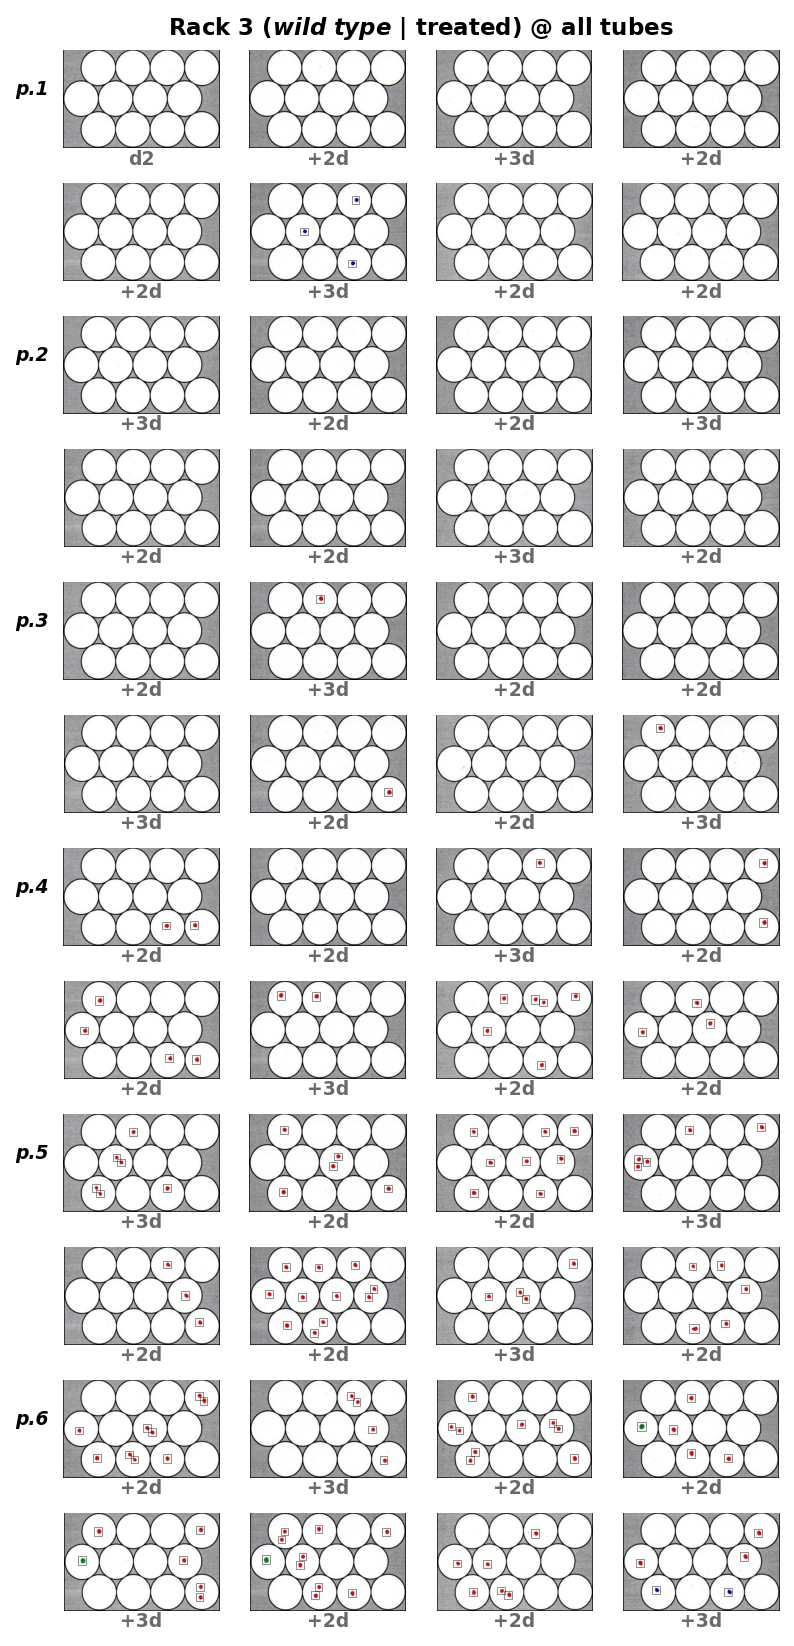

In [9]:
from drosben.experiment.manager import qc_mosaic
qc_mosaic(
    obs = example_experiment.sequence,
    infodict = example_experiment.infos,
    storepath = example_experiment.storepath,
    mode = "rack", # whether to plot whole racks or individual tubes
    rack_no = 3,   # which rack to plot
                   # by default, each rack will be labelled by the time interval
                   # (in days) since the previous observation
);

Here, detected events are outlined by black boxes, and we can see that all events were detected and there are no false positives.

We can get more detail if we inspect the tubes one by one and, instead of marking each data point by the time difference with the previous (+ X days), we plot the number of days since the start date. Let us do this for tube 5 from rack 3:

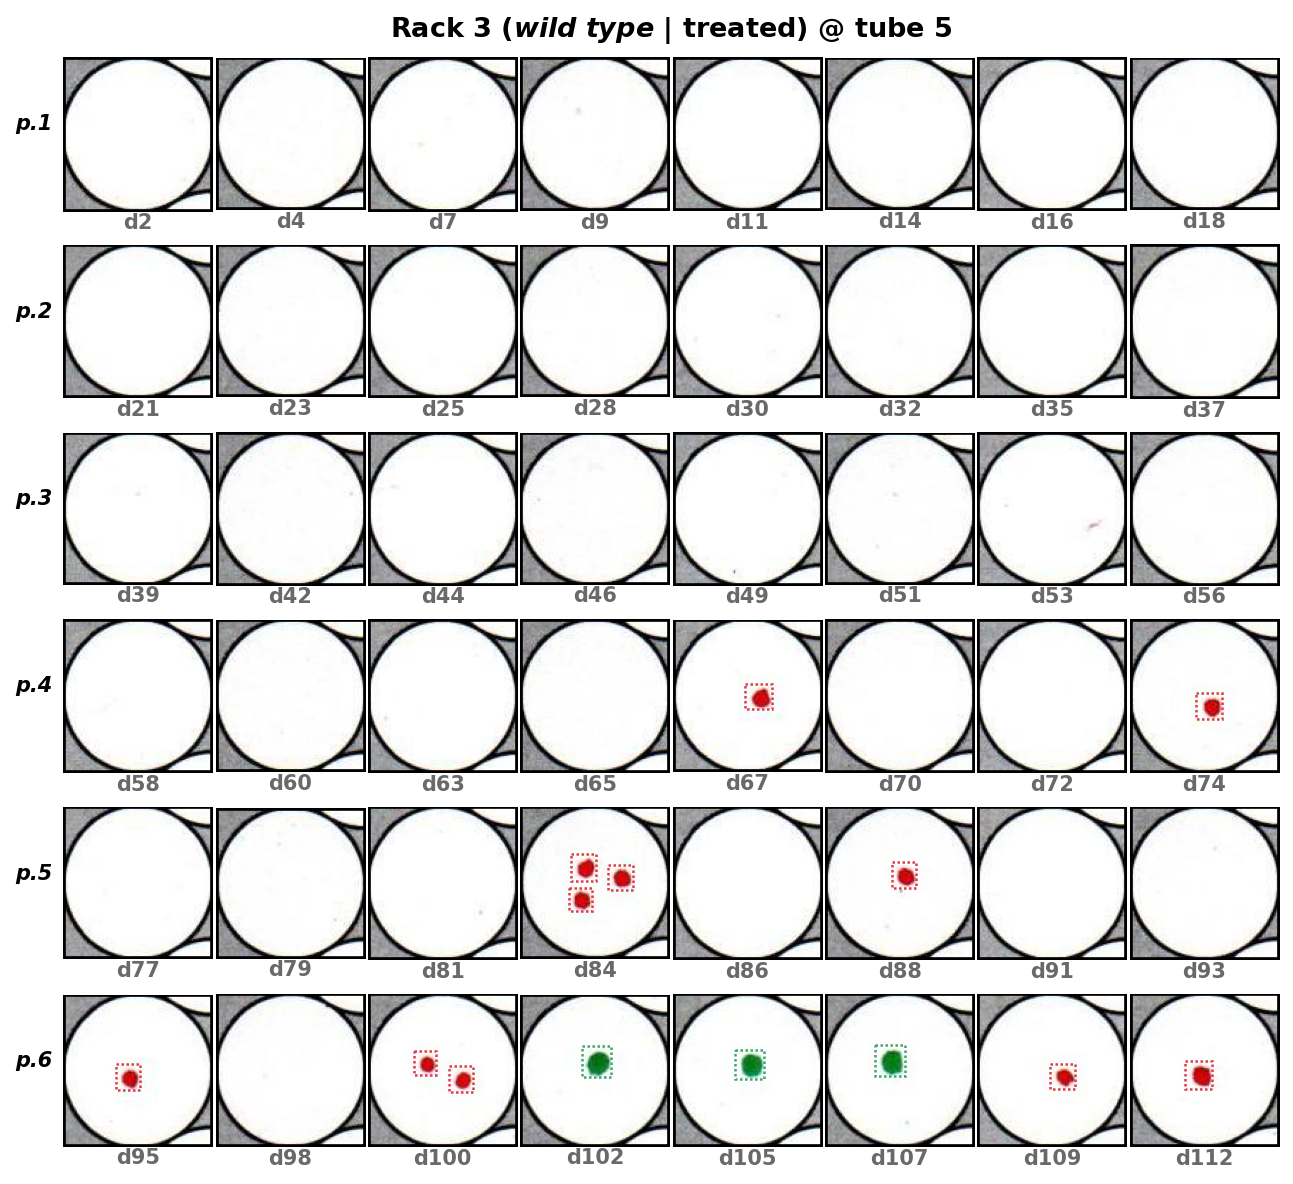

In [10]:
# inspection of tube 2 from rack 2
qc_mosaic(
    obs = example_experiment.sequence,
    infodict = example_experiment.infos,
    storepath = example_experiment.storepath,
    mode = "tube",
    day_label = 'absolute',
    rack_no = 3,
    tube_no = 5
);

Note that in this mode:
- you can inspect not only whether the outlines identify all events (and whether there are false positives) but also whether the colour has been appropriately identified.
- you can visualise stretches of carried-over events that resolve later, like the fly that died on day 102 and was falling on the new tube until it finally got stuck to the food on day 109.

---
# 3C. Gather and clean event data

To move on to _survival analysis_, we need a one-event-per-row dataset. This is done in a few steps that can be chained to do in immediate succession, but here we will demonstrate their functionality individually.

## Overview

- `collate_experiment_data` does most of the data cleaning, by
    - screening the full chronological record and keeping only the information about each event that is relevant for analysis (time and experimental variables);
    - removing pen marks that are not in the expected colours (considered scratches/stains/errors);
    - removing carried-overs [as indicated in the diagram above](./02_Perform_Experiment.ipynb#carried_over_diagram); and
    - comparing the number of observations made per tube with the number of individuals declared in the experiment metadata;
    - recording the discrepancies; and
    - adding (to the feedback text) comments that outline these observations and the user's options.


- `Experiment.consolidate_observations` squares some the discrepancies where a tube has yielded less events than its initial number of flies, by
    - censoring them _at the start_ of the experiment (`mode='atStart'`), if the user considers that the events were likely censorings (or deaths) that passed undetected and it is now impossible to figure out when they happened (statistically, this is equivalent to removing them from the experiment); or
    - censoring them _at the end_ of the experiment (`mode='atEnd'`), if the user wants to analyse partial data (i.e. before the experiment is concluded) or they decide to cut the experiment short (i.e. survival is quickly down to 0 in some experimental arms while in others most flies are still alive).


- Note _excess_ events are ignored - Drosben considers they were errors in the experimental metadata - users are encouraged to use `qa_mosaic` in `tube` mode to explore whether these excess events are false positives, and remove them manually using the `drop` method.

Let's first compile the event-based dataset and have a look at the discrepancies between expected events and initial numbers of flies:

In [11]:
from drosben.experiment.manager import collate_experiment_data
feedback_text, fly_numbers_dict = collate_experiment_data(
    experiments_updated, # pass on the list of experiments that have been just updated
    feedback_text,       # this will be extended with additional details
    OW = True,           # same as before - observations will be stored in disk if True
    dry_run = False,     # same as before
)

# we print only the part of the feedback that pertains to fly number discrepancies
for key in feedback_text.keys():
    if 'fly' in key:
        print(f"\n{key}:\n—————————————————————————————————————————————————————")
        if isinstance(feedback_text[key], list):
            for x in feedback_text[key]:
                print(x)
        else:
            print(feedback_text[key])


fly_numbers:
—————————————————————————————————————————————————————

Please consider the following information:

* TUBES WITH MISSING EVENTS.  

There are missing events observed in rack 2, tube(s) 2, 3. 
These were expected to contain initially 10, 10 flies (respectively).
But the observations recorded are only 2, 8 (respectively).

There are missing events observed in rack 4, tube(s) 12. 
This was expected to contain initially 10 flies.
But the observations recorded are only 9.

    The analysis will proceed with the current data (stored in the Excel file:
    /Users/JQ/Drosben_userdata/experiments_data/02.02.2022_Effect-of-myfavouritegene-on-lifespan_bd8b2f79/bd8b2f79_observations.xlsx,  
    and assuming that the original number of flies matches the number of observations. 
    A more stringent analysis would consider the missing flies as censored at day 1,
    or at the end of the experiment if these missing events come from ending the experiment
    before all individuals have di

---

So, it seems clear that there are some discrepancies we need to think about:
- All tubes with excess events are in rack 4. It is only one in each affected tube, so it is probably safe to ignore it, but it is worth checking that those datasheets are not having a systematic problem of over-detection (false positives).
- Two tubes are missing just one or two events, so this could be just errors in accounting for the initial number of flies. It would not matter much if we censor them at the start or the end, but tube 2 in rack 2 is missing eight! We should inspect it.

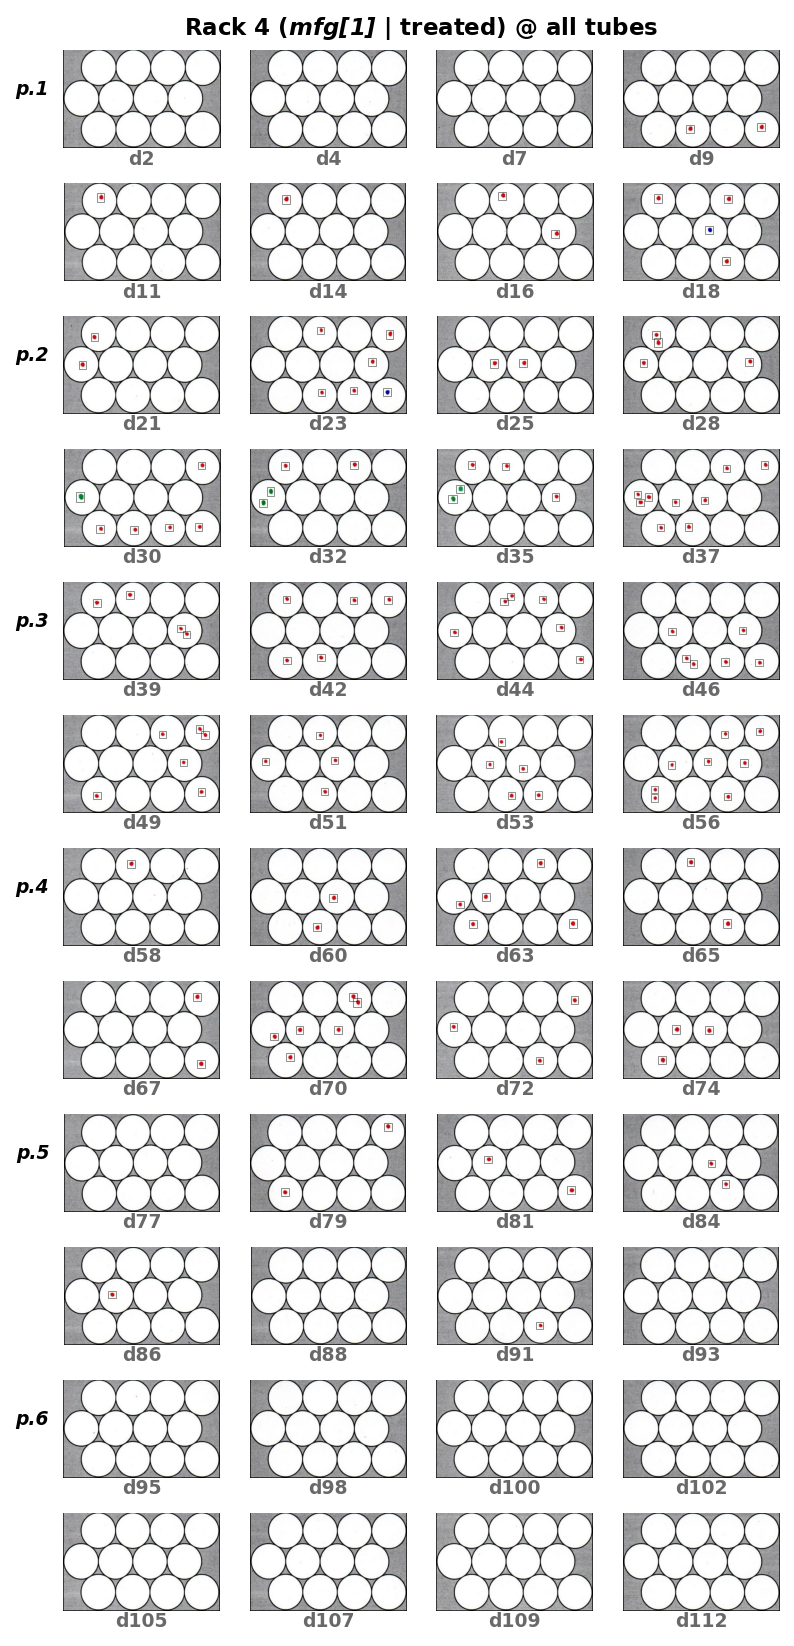

In [12]:
# inspection of RACK 4
qc_mosaic(
    obs = example_experiment.sequence,
    infodict = infodict_list[0][1],
    storepath = example_experiment.storepath,
    mode = "rack",
    rack_no = 4,
    day_label = 'absolute');

---

All seems in order - all the bounding boxes are outlining genuine marks, so the excess are probably human errors, more likely at the beginning of the experiment, so these seem safe to ignore.

Let us now have a look at tube 2 from rack 2:

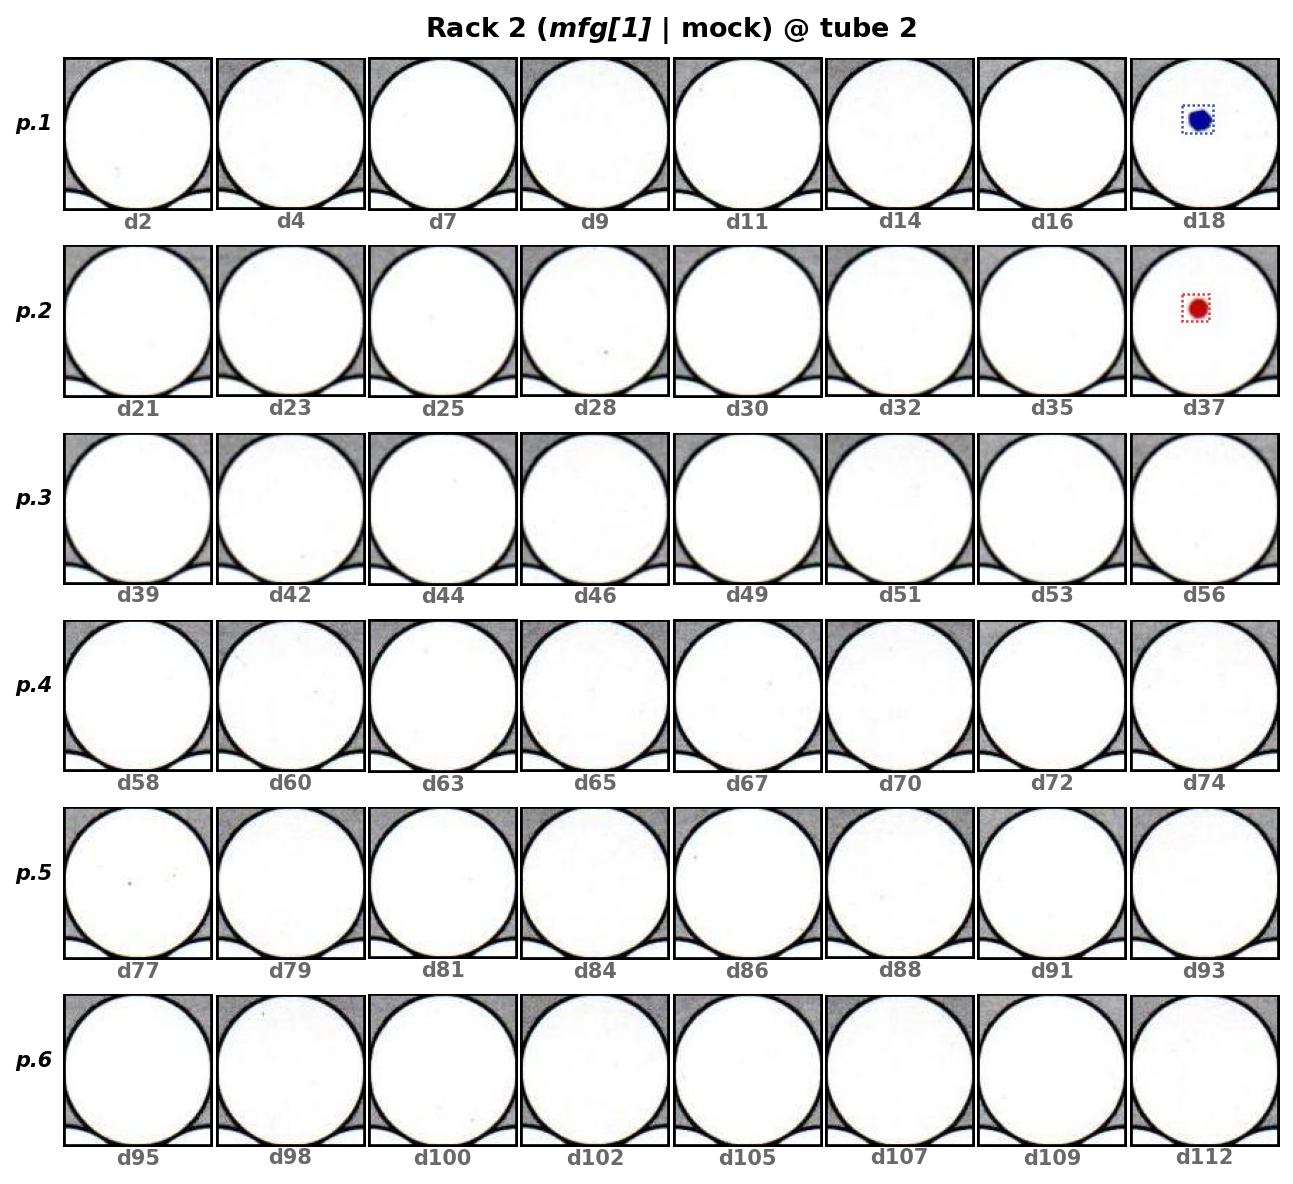

In [13]:
# inspection of tube 2 from rack 2
qc_mosaic(
    obs = example_experiment.sequence,
    infodict = infodict_list[0][1],
    storepath = example_experiment.storepath,
    mode = "tube",
    day_label = 'absolute',
    rack_no = 2,
    tube_no = 2
);

There seems to be a problem here - there's been some censoring, and this is the only tube that has far fewer events than expected. It seems reasonable to assume that the user may have placed 11 or 9 flies instead of 10 in a few tubes, but not that they would put just 2 in one. So we are going to assume that there were unrecorded censorings (maybe a 'mass escape' on one day?) and therefore I will consolidate the data by censoring all missing observations (in all tubes) at the start of the experiment (so, in practice, removing them from statistical consideration).

>**Note on usage:**`collate_experiment_data` stores the discrepancy data in `fly_numbers_dict`, but it will consider any experiments where data has been updated, so it tags the discrepancy data of each experiment using the experiment's `xid` (even if in this case there are no data from other Experiments being considered):

In [14]:
our_xid = example_experiment.infos['xid']
our_fly_number_discrepancies = fly_numbers_dict[our_xid]
example_experiment.consolidate_observations(our_fly_number_discrepancies, mode = 'atStart') # note the mode option

Now, all the event-based data is contained in the `Experiment` attribute `observ_dict`:

In [15]:
example_experiment.observ_dict['Observ_raw_readable'] # 'Observ_raw_readable' = Excel sheet name

,Date,Day_no.,Event_type,Rack_no.,Tube_no.,genotype,treatment,Event
0,2022-02-25,23,Dead,1,1,wild-type,mock,1
1,2022-03-09,35,Dead,1,1,wild-type,mock,1
2,2022-03-30,56,Dead,1,1,wild-type,mock,1
3,2022-04-13,70,Dead,1,1,wild-type,mock,1
4,2022-04-24,81,Dead,1,1,wild-type,mock,1
...,...,...,...,...,...,...,...,...
468,2022-03-20,46,Dead,4,12,mfg[1],treated,1
469,2022-03-23,49,Dead,4,12,mfg[1],treated,1
470,2022-04-06,63,Dead,4,12,mfg[1],treated,1
471,2022-04-10,67,Dead,4,12,mfg[1],treated,1


---
For the statistical analysis, we will use the clean, trimmed version:

In [16]:
example_experiment.observ_dict['Observ_m2c_atStart_analysis'] # missing to censorings at start

,Day_no.,Rack_no.,Tube_no.,genotype,treatment,Event
0,1,2,2,mfg[1],mock,0
1,1,2,2,mfg[1],mock,0
2,1,2,2,mfg[1],mock,0
3,1,2,2,mfg[1],mock,0
4,1,2,2,mfg[1],mock,0
...,...,...,...,...,...,...
479,112,3,4,wild-type,treated,1
480,112,3,5,wild-type,treated,1
481,112,3,8,wild-type,treated,1
482,112,3,9,wild-type,treated,0


(There are more columns now because of the missing flies added).

Now we only need to save this to disk:

In [17]:
example_experiment.save_observations()

---
**END**

---